In [7]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="Malgun Gothic")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

DATA_PATH = Path("results/result_sample_shorts_all_for_video_agent_fixed.csv")

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print(df.shape)


(200, 75)


In [8]:
numeric_cols = [
    "avg_brightness",
    "avg_blue",
    "avg_green",
    "avg_red",
    "person_ratio",
    "face_ratio",
    "text_ratio",
]

categorical_cols = [
    "production_quality",
    "lighting_style",
    "color_mood",
    "editing_pace",
    "motion_graphic",
    "video_format",
    "first_3sec",
    "background_style",
]

numeric_cols = [col for col in numeric_cols if col in df.columns]
categorical_cols = [col for col in categorical_cols if col in df.columns]

df["target"] = df["success_label"].map({
    "fail": 0,
    "success": 1
})

ml_features = numeric_cols + categorical_cols

ml_df = df[ml_features + ["target", "domain"]].dropna(subset=["target"]).copy()

print("수치형 변수:", numeric_cols)
print("범주형 변수:", categorical_cols)
print("분석 데이터 크기:", ml_df.shape)

display(ml_df["target"].value_counts())

수치형 변수: ['avg_brightness', 'avg_blue', 'avg_green', 'avg_red', 'person_ratio', 'face_ratio', 'text_ratio']
범주형 변수: ['production_quality', 'lighting_style', 'color_mood', 'editing_pace', 'motion_graphic', 'video_format', 'first_3sec', 'background_style']
분석 데이터 크기: (200, 17)


target
0    110
1     90
Name: count, dtype: int64

In [9]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

In [10]:
X = ml_df[ml_features]
y = ml_df["target"]

logit_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logit_auc_scores = cross_val_score(
    logit_model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

logit_f1_scores = cross_val_score(
    logit_model,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print("Logistic Regression ROC-AUC:", np.round(logit_auc_scores, 3))
print("평균 ROC-AUC:", round(logit_auc_scores.mean(), 3))
print("Logistic Regression F1:", np.round(logit_f1_scores, 3))
print("평균 F1:", round(logit_f1_scores.mean(), 3))

Logistic Regression ROC-AUC: [0.573 0.758 0.566 0.596 0.422]
평균 ROC-AUC: 0.583
Logistic Regression F1: [0.541 0.667 0.514 0.605 0.378]
평균 F1: 0.541


In [11]:
logit_model.fit(X, y)

preprocessor = logit_model.named_steps["preprocess"]
model = logit_model.named_steps["model"]

num_feature_names = numeric_cols
cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)

feature_names = list(num_feature_names) + list(cat_feature_names)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": model.coef_[0]
})

coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

display(coef_df.head(30))

,feature,coef,abs_coef
19,editing_pace_매우 느림,-1.508457,1.508457
35,video_format_웹드라마,1.074804,1.074804
38,video_format_인터뷰,-0.944631,0.944631
22,editing_pace_빠름,0.904327,0.904327
8,production_quality_일반,0.843157,0.843157
20,editing_pace_매우 빠름,0.756326,0.756326
14,color_mood_무채색,-0.735858,0.735858
5,face_ratio,0.726941,0.726941
33,video_format_에피소드소개,-0.689389,0.689389
50,background_style_혼합,0.672519,0.672519


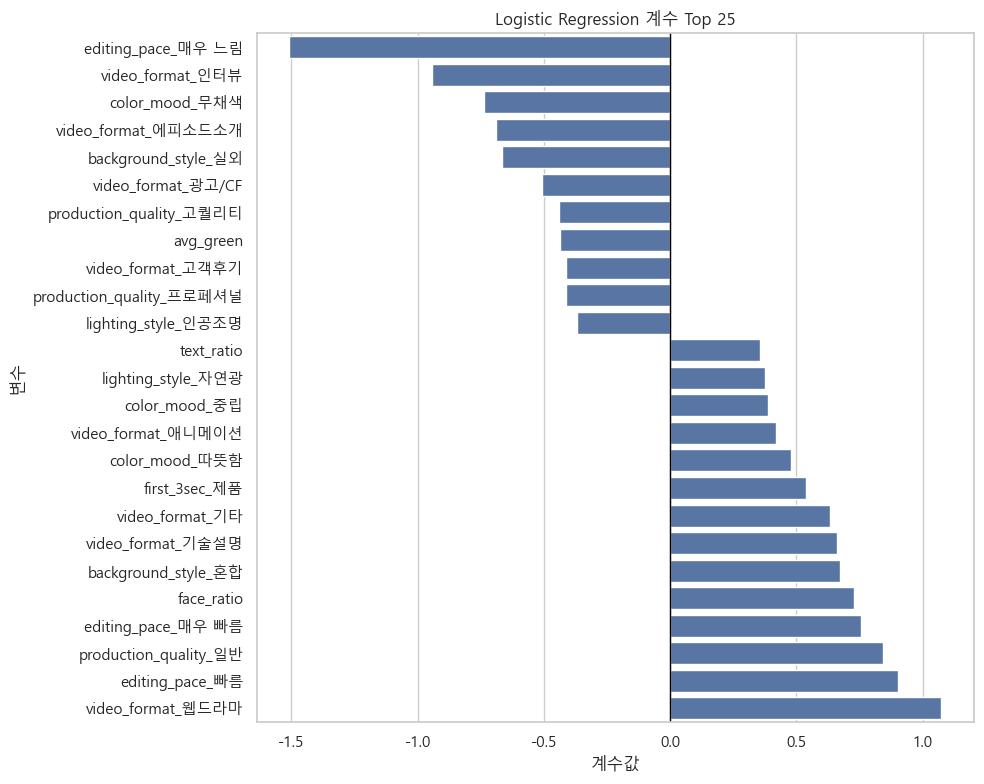

In [12]:
top_coef = coef_df.head(25).sort_values("coef")

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_coef,
    x="coef",
    y="feature"
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Logistic Regression 계수 Top 25")
plt.xlabel("계수값")
plt.ylabel("변수")
plt.tight_layout()
plt.show()

- coef > 0: 성공 영상 쪽과 관련된 변수
- coef < 0: 실패 영상 쪽과 관련된 변수
- abs_coef가 클수록 성공/실패 구분에 더 크게 기여한 후보 변수

In [13]:
rf_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=500,
            max_depth=4,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

rf_auc_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

rf_f1_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print("Random Forest ROC-AUC:", np.round(rf_auc_scores, 3))
print("평균 ROC-AUC:", round(rf_auc_scores.mean(), 3))
print("Random Forest F1:", np.round(rf_f1_scores, 3))
print("평균 F1:", round(rf_f1_scores.mean(), 3))

Random Forest ROC-AUC: [0.553 0.641 0.601 0.654 0.53 ]
평균 ROC-AUC: 0.596
Random Forest F1: [0.486 0.564 0.345 0.615 0.474]
평균 F1: 0.497


In [14]:
rf_model.fit(X, y)

preprocessor = rf_model.named_steps["preprocess"]
rf = rf_model.named_steps["model"]

cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)
feature_names = list(numeric_cols) + list(cat_feature_names)

rf_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

display(rf_importance_df.head(30))

,feature,importance
0,avg_brightness,0.146392
2,avg_green,0.111215
3,avg_red,0.109331
4,person_ratio,0.085011
1,avg_blue,0.080919
5,face_ratio,0.068591
6,text_ratio,0.057101
38,video_format_인터뷰,0.025642
27,video_format_광고/CF,0.025149
22,editing_pace_빠름,0.024076


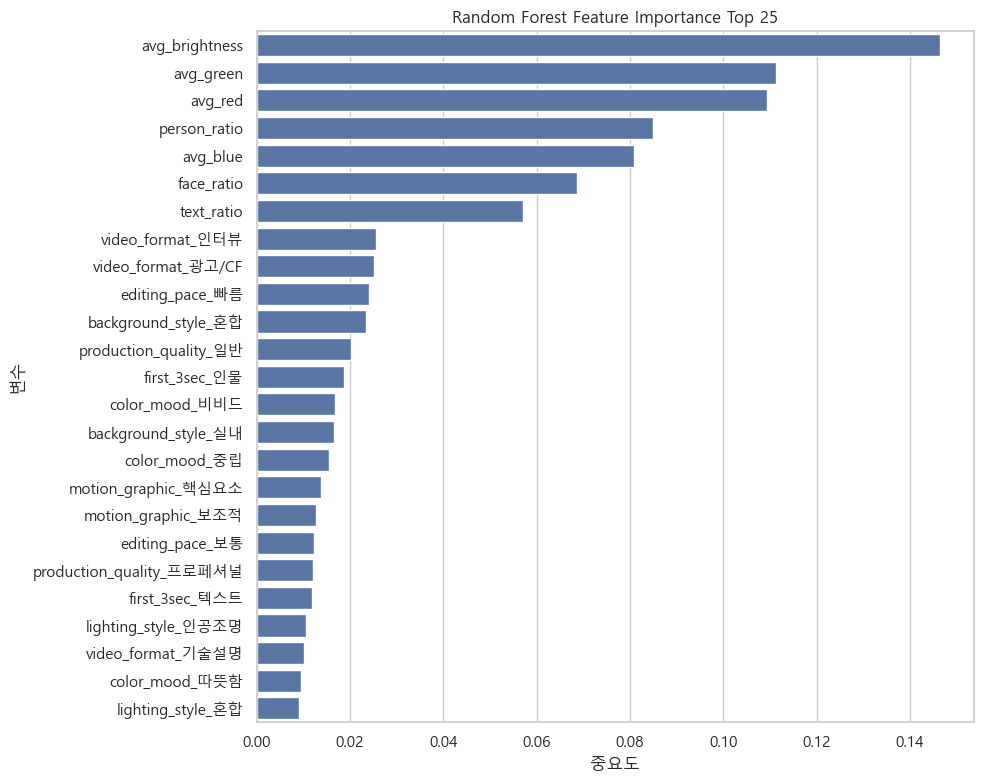

In [15]:
top_rf_importance = rf_importance_df.head(25)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_rf_importance,
    x="importance",
    y="feature"
)
plt.title("Random Forest Feature Importance Top 25")
plt.xlabel("중요도")
plt.ylabel("변수")
plt.tight_layout()
plt.show()

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

rf_model.fit(X_train, y_train)

perm_result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)

display(perm_df)

,feature,importance_mean,importance_std
0,avg_brightness,0.033766,0.021304
2,avg_green,0.026245,0.016835
4,person_ratio,0.018994,0.023778
12,video_format,0.017803,0.012202
7,production_quality,0.016071,0.014235
13,first_3sec,0.014394,0.014280
3,avg_red,0.008983,0.021556
5,face_ratio,0.007305,0.020999
6,text_ratio,0.006764,0.013433
11,motion_graphic,0.000703,0.008849


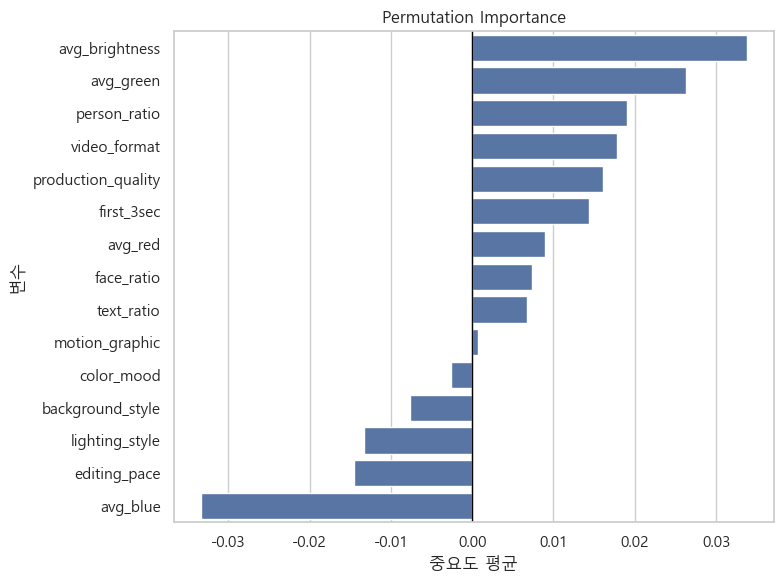

In [17]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=perm_df.sort_values("importance_mean", ascending=False),
    x="importance_mean",
    y="feature"
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Permutation Importance")
plt.xlabel("중요도 평균")
plt.ylabel("변수")
plt.tight_layout()
plt.show()

In [18]:
def run_domain_model(domain_name):
    temp = ml_df[ml_df["domain"] == domain_name].copy()
    
    X_domain = temp[ml_features]
    y_domain = temp["target"]
    
    print("=" * 80)
    print(f"Domain: {domain_name}")
    print("데이터 크기:", temp.shape)
    print(y_domain.value_counts())
    
    domain_preprocess = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ]
    )
    
    domain_rf = Pipeline(
        steps=[
            ("preprocess", domain_preprocess),
            ("model", RandomForestClassifier(
                n_estimators=500,
                max_depth=3,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=42
            ))
        ]
    )
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    auc_scores = cross_val_score(
        domain_rf,
        X_domain,
        y_domain,
        cv=cv,
        scoring="roc_auc"
    )
    
    f1_scores = cross_val_score(
        domain_rf,
        X_domain,
        y_domain,
        cv=cv,
        scoring="f1"
    )
    
    print("ROC-AUC:", np.round(auc_scores, 3))
    print("평균 ROC-AUC:", round(auc_scores.mean(), 3))
    print("F1:", np.round(f1_scores, 3))
    print("평균 F1:", round(f1_scores.mean(), 3))
    
    domain_rf.fit(X_domain, y_domain)
    
    preprocessor = domain_rf.named_steps["preprocess"]
    model = domain_rf.named_steps["model"]
    
    cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)
    feature_names = list(numeric_cols) + list(cat_feature_names)
    
    importance_df = pd.DataFrame({
        "domain": domain_name,
        "feature": feature_names,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)
    
    display(importance_df.head(20))
    
    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=importance_df.head(20),
        x="importance",
        y="feature"
    )
    plt.title(f"{domain_name} Random Forest Feature Importance Top 20")
    plt.xlabel("중요도")
    plt.ylabel("변수")
    plt.tight_layout()
    plt.show()
    
    return {
        "domain": domain_name,
        "model": domain_rf,
        "importance_df": importance_df,
        "auc_scores": auc_scores,
        "f1_scores": f1_scores
    }

Domain: FnB
데이터 크기: (100, 17)
target
0    52
1    48
Name: count, dtype: int64
ROC-AUC: [0.726 0.805 0.761]
평균 ROC-AUC: 0.764
F1: [0.684 0.69  0.645]
평균 F1: 0.673


,domain,feature,importance
0,FnB,avg_brightness,0.104680
4,FnB,person_ratio,0.102836
3,FnB,avg_red,0.100049
5,FnB,face_ratio,0.097610
2,FnB,avg_green,0.089610
23,FnB,motion_graphic_핵심요소,0.073833
21,FnB,motion_graphic_보조적,0.069223
1,FnB,avg_blue,0.066799
6,FnB,text_ratio,0.044601
38,FnB,first_3sec_인물,0.044437


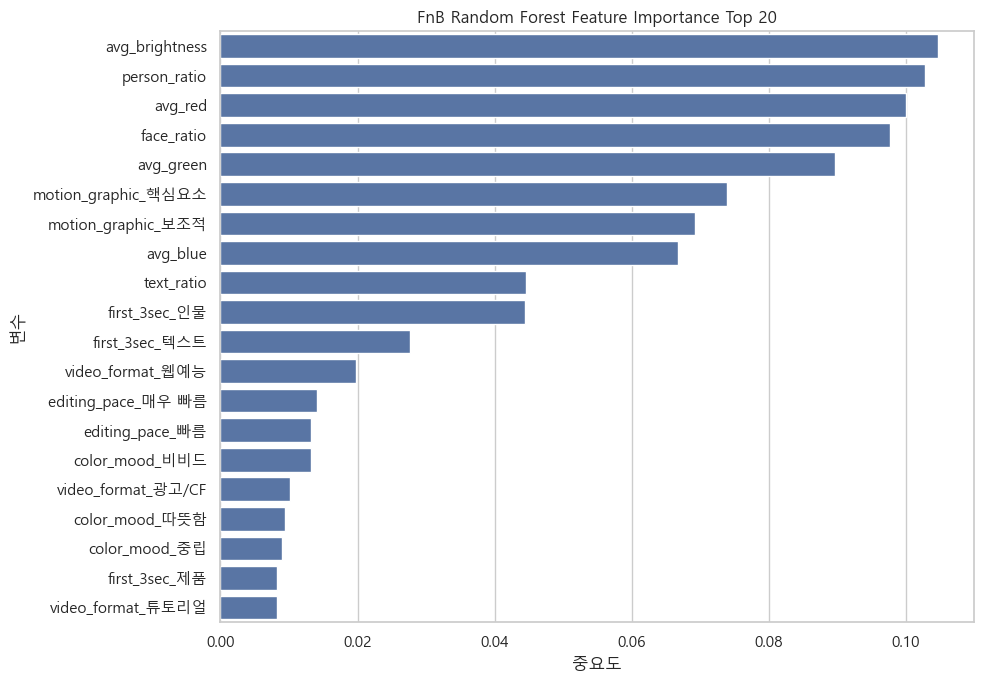

Domain: IT
데이터 크기: (100, 17)
target
0    58
1    42
Name: count, dtype: int64
ROC-AUC: [0.618 0.504 0.801]
평균 ROC-AUC: 0.641
F1: [0.545 0.429 0.71 ]
평균 F1: 0.561


,domain,feature,importance
2,IT,avg_green,0.111014
3,IT,avg_red,0.093718
0,IT,avg_brightness,0.089741
1,IT,avg_blue,0.089521
5,IT,face_ratio,0.072491
4,IT,person_ratio,0.069225
24,IT,motion_graphic_핵심요소,0.049244
23,IT,motion_graphic_보조적,0.047611
41,IT,first_3sec_텍스트,0.043123
6,IT,text_ratio,0.039539


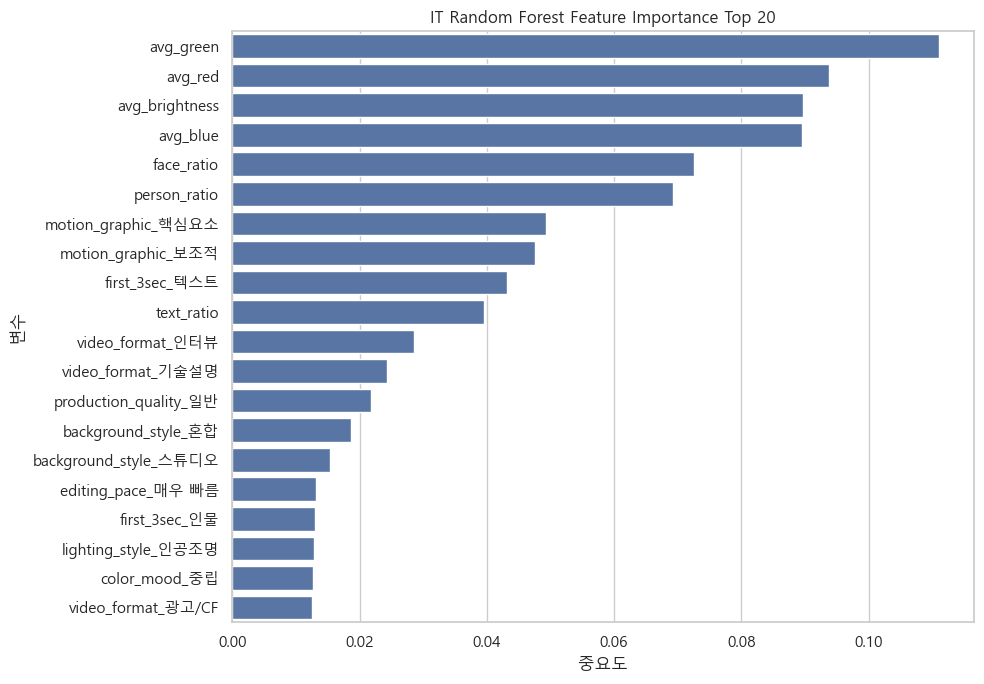

In [19]:
fnb_ml_result = run_domain_model("FnB")
it_ml_result = run_domain_model("IT")

# 8. SHAP 기반 모델 해석

Random Forest 모델의 변수 중요도를 보완하기 위해 SHAP을 활용한다.  
SHAP 결과는 예측 모델의 확정적 근거가 아니라, 모델이 성공/실패 구분에 어떤 변수를 상대적으로 활용했는지 확인하기 위한 보조 분석으로 해석한다.

In [20]:
import shap
from scipy import sparse
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [21]:
def get_feature_names(preprocessor, numeric_cols, categorical_cols):
    """
    ColumnTransformer 이후 feature name 추출
    """
    num_feature_names = numeric_cols
    
    cat_encoder = preprocessor.named_transformers_["cat"]
    cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols)
    
    return list(num_feature_names) + list(cat_feature_names)


def to_dense_if_sparse(x):
    """
    sparse matrix면 dense로 변환
    """
    if sparse.issparse(x):
        return x.toarray()
    return x


def get_success_class_shap_values(shap_values):
    """
    SHAP 버전에 따라 binary classifier shap_values 형태가 다를 수 있어 success class 기준으로 통일
    """
    # 구버전: list 형태 [class0, class1]
    if isinstance(shap_values, list):
        return shap_values[1]
    
    # 신버전: (n_samples, n_features, n_classes)
    if len(shap_values.shape) == 3:
        return shap_values[:, :, 1]
    
    # 이미 (n_samples, n_features)
    return shap_values


def map_to_original_feature(encoded_feature, numeric_cols, categorical_cols):
    """
    One-hot feature를 원래 변수명으로 매핑
    예: motion_graphic_핵심요소 -> motion_graphic
    """
    if encoded_feature in numeric_cols:
        return encoded_feature
    
    for col in categorical_cols:
        prefix = col + "_"
        if encoded_feature.startswith(prefix):
            return col
    
    return encoded_feature


def aggregate_shap_by_original_feature(shap_importance_df, numeric_cols, categorical_cols):
    """
    one-hot level별 SHAP 중요도를 원래 변수 단위로 합산
    """
    temp = shap_importance_df.copy()
    temp["original_feature"] = temp["feature"].apply(
        lambda x: map_to_original_feature(x, numeric_cols, categorical_cols)
    )
    
    agg = (
        temp.groupby("original_feature")["mean_abs_shap"]
        .sum()
        .reset_index()
        .sort_values("mean_abs_shap", ascending=False)
    )
    
    return agg

In [22]:
def run_domain_shap(domain_name):
    temp = ml_df[ml_df["domain"] == domain_name].copy()
    
    X_domain = temp[ml_features]
    y_domain = temp["target"]
    
    print("=" * 80)
    print(f"Domain: {domain_name}")
    print("데이터 크기:", temp.shape)
    display(y_domain.value_counts())
    
    preprocess = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ]
    )
    
    rf_model = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(
                n_estimators=500,
                max_depth=3,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=42
            ))
        ]
    )
    
    # 모델 학습
    rf_model.fit(X_domain, y_domain)
    
    preprocessor = rf_model.named_steps["preprocess"]
    model = rf_model.named_steps["model"]
    
    X_transformed = preprocessor.transform(X_domain)
    X_transformed = to_dense_if_sparse(X_transformed)
    
    feature_names = get_feature_names(
        preprocessor,
        numeric_cols,
        categorical_cols
    )
    
    X_transformed_df = pd.DataFrame(
        X_transformed,
        columns=feature_names,
        index=X_domain.index
    )
    
    # SHAP 계산
    explainer = shap.TreeExplainer(model)
    shap_values_raw = explainer.shap_values(X_transformed_df)
    shap_values_success = get_success_class_shap_values(shap_values_raw)
    
    # one-hot feature 단위 중요도
    shap_importance_df = pd.DataFrame({
        "domain": domain_name,
        "feature": feature_names,
        "mean_abs_shap": np.abs(shap_values_success).mean(axis=0),
        "mean_shap": shap_values_success.mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False)
    
    # 원래 변수 단위 중요도
    shap_original_importance_df = aggregate_shap_by_original_feature(
        shap_importance_df,
        numeric_cols,
        categorical_cols
    )
    
    shap_original_importance_df.insert(0, "domain", domain_name)
    
    print("SHAP 중요도 Top 20 - One-hot feature 기준")
    display(shap_importance_df.head(20))
    
    print("SHAP 중요도 - 원래 변수 기준")
    display(shap_original_importance_df)
    
    # SHAP bar plot
    plt.figure(figsize=(10, 7))
    top_plot_df = shap_importance_df.head(20).sort_values("mean_abs_shap")
    plt.barh(top_plot_df["feature"], top_plot_df["mean_abs_shap"])
    plt.title(f"{domain_name} SHAP Importance Top 20")
    plt.xlabel("Mean |SHAP value|")
    plt.tight_layout()
    plt.show()
    
    # 원래 변수 단위 bar plot
    plt.figure(figsize=(9, 6))
    top_original_df = shap_original_importance_df.head(15).sort_values("mean_abs_shap")
    plt.barh(top_original_df["original_feature"], top_original_df["mean_abs_shap"])
    plt.title(f"{domain_name} SHAP Importance by Original Feature")
    plt.xlabel("Sum of Mean |SHAP value|")
    plt.tight_layout()
    plt.show()
    
    # SHAP summary plot
    print(f"{domain_name} SHAP summary plot")
    shap.summary_plot(
        shap_values_success,
        X_transformed_df,
        max_display=20,
        show=True
    )
    
    return {
        "domain": domain_name,
        "model": rf_model,
        "X_transformed_df": X_transformed_df,
        "shap_values_success": shap_values_success,
        "shap_importance_df": shap_importance_df,
        "shap_original_importance_df": shap_original_importance_df,
    }

Domain: FnB
데이터 크기: (100, 17)


target
0    52
1    48
Name: count, dtype: int64

SHAP 중요도 Top 20 - One-hot feature 기준


,domain,feature,mean_abs_shap,mean_shap
4,FnB,person_ratio,0.037317,-0.000551
23,FnB,motion_graphic_핵심요소,0.030859,-0.000811
21,FnB,motion_graphic_보조적,0.030654,-0.000199
5,FnB,face_ratio,0.029551,-0.000174
0,FnB,avg_brightness,0.027597,-0.001343
3,FnB,avg_red,0.026327,-0.001943
2,FnB,avg_green,0.023507,0.000175
38,FnB,first_3sec_인물,0.020623,-0.000257
1,FnB,avg_blue,0.013904,-0.001147
41,FnB,first_3sec_텍스트,0.013252,0.000482


SHAP 중요도 - 원래 변수 기준


,domain,original_feature,mean_abs_shap
10,FnB,motion_graphic,0.061513
11,FnB,person_ratio,0.037317
8,FnB,first_3sec,0.036362
7,FnB,face_ratio,0.029551
1,FnB,avg_brightness,0.027597
3,FnB,avg_red,0.026327
2,FnB,avg_green,0.023507
14,FnB,video_format,0.014189
0,FnB,avg_blue,0.013904
13,FnB,text_ratio,0.011972


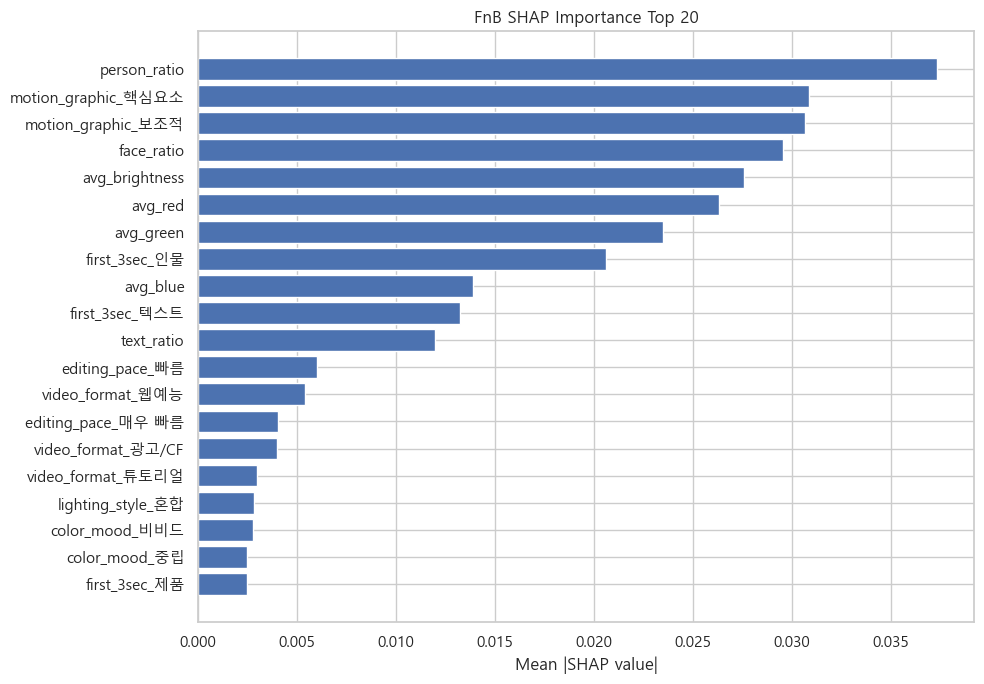

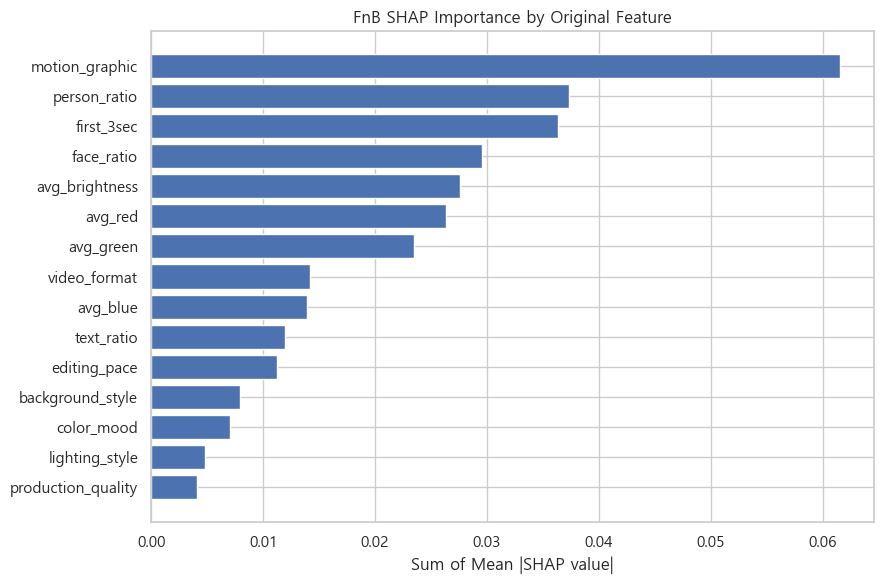

FnB SHAP summary plot


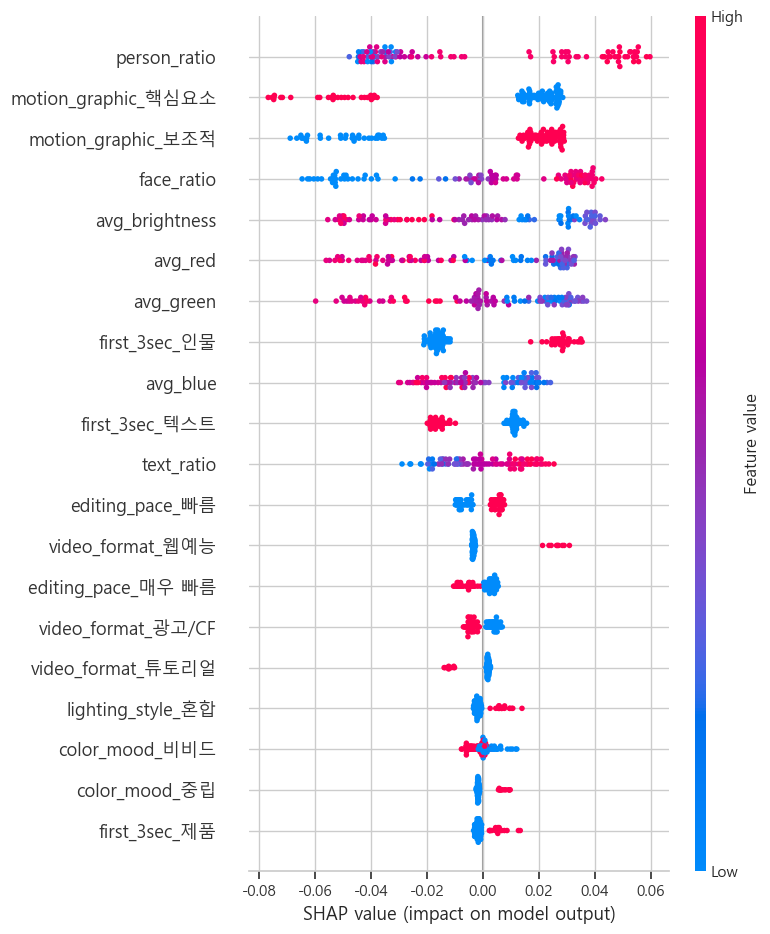

Domain: IT
데이터 크기: (100, 17)


target
0    58
1    42
Name: count, dtype: int64

SHAP 중요도 Top 20 - One-hot feature 기준


,domain,feature,mean_abs_shap,mean_shap
3,IT,avg_red,0.020755,-0.003192
23,IT,motion_graphic_보조적,0.020744,-0.001435
24,IT,motion_graphic_핵심요소,0.020149,-0.001103
2,IT,avg_green,0.019964,-0.001499
41,IT,first_3sec_텍스트,0.017564,-0.000502
0,IT,avg_brightness,0.015743,-0.001361
1,IT,avg_blue,0.015243,-0.001326
4,IT,person_ratio,0.011748,-0.001922
5,IT,face_ratio,0.011016,-0.001541
35,IT,video_format_인터뷰,0.008677,-0.000155


SHAP 중요도 - 원래 변수 기준


,domain,original_feature,mean_abs_shap
10,IT,motion_graphic,0.040893
14,IT,video_format,0.026672
8,IT,first_3sec,0.022917
3,IT,avg_red,0.020755
2,IT,avg_green,0.019964
1,IT,avg_brightness,0.015743
0,IT,avg_blue,0.015243
4,IT,background_style,0.014028
12,IT,production_quality,0.012624
6,IT,editing_pace,0.012215


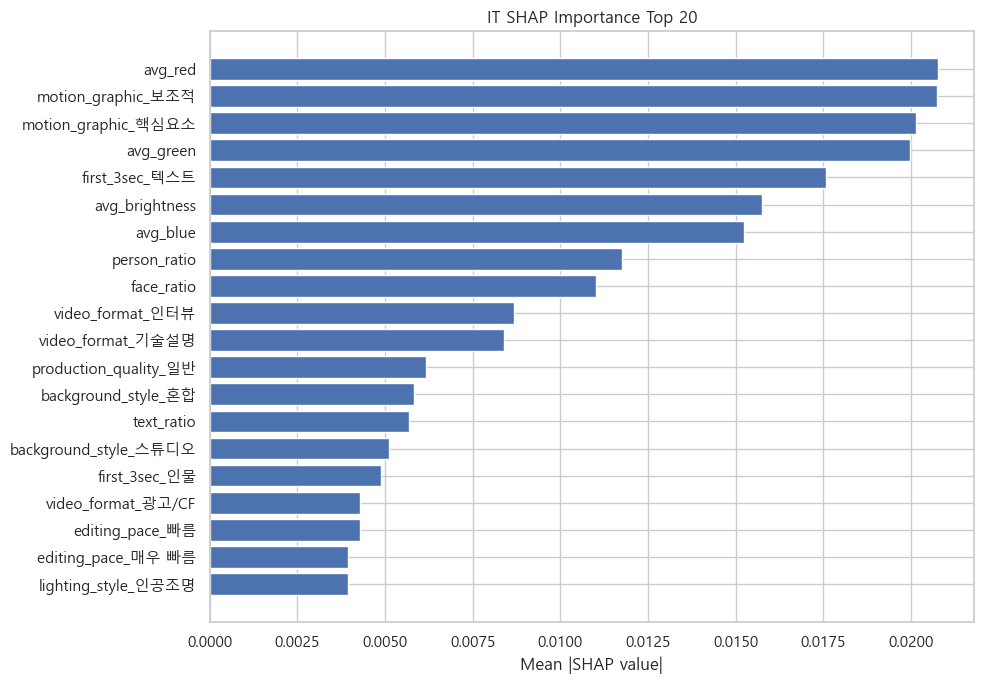

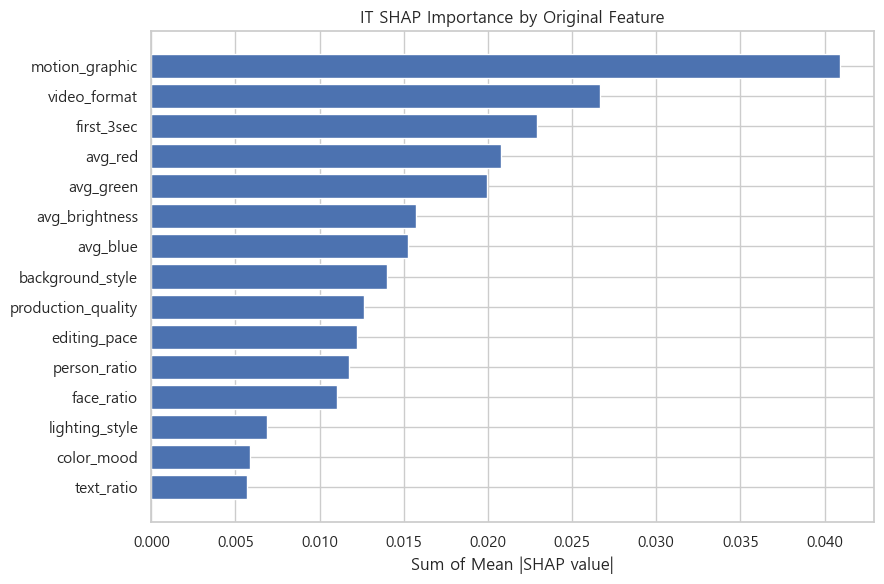

IT SHAP summary plot


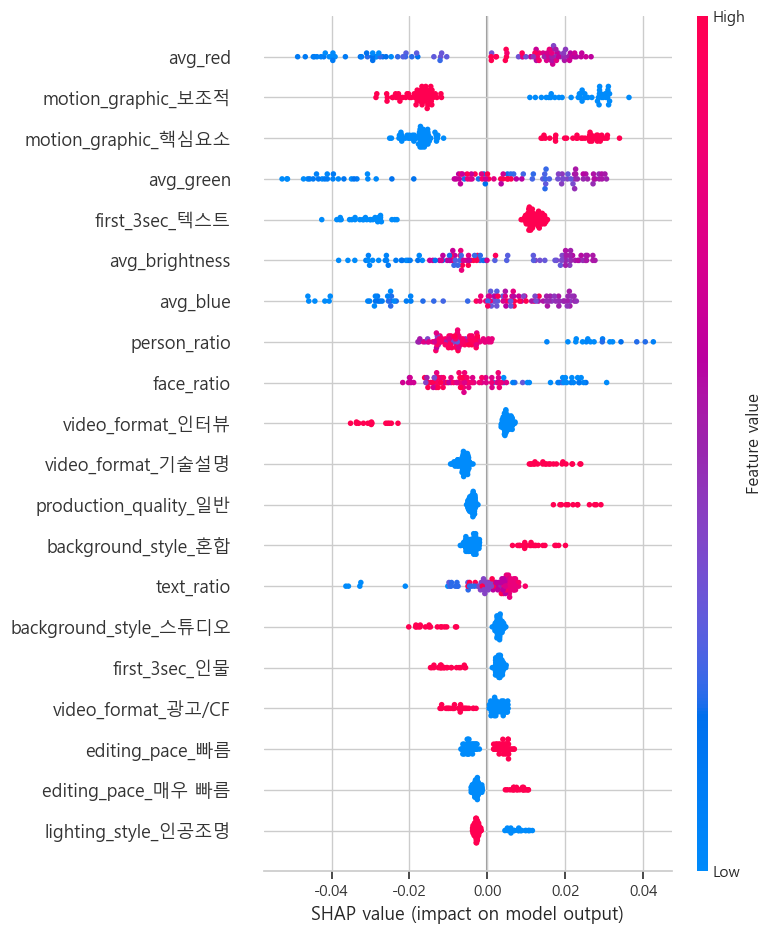

In [23]:
fnb_shap_result = run_domain_shap("FnB")
it_shap_result = run_domain_shap("IT")

In [24]:
shap_importance_all_df = pd.concat(
    [
        fnb_shap_result["shap_importance_df"],
        it_shap_result["shap_importance_df"],
    ],
    ignore_index=True
)

shap_original_importance_all_df = pd.concat(
    [
        fnb_shap_result["shap_original_importance_df"],
        it_shap_result["shap_original_importance_df"],
    ],
    ignore_index=True
)

print("One-hot feature 기준 SHAP 중요도")
display(
    shap_importance_all_df.sort_values(
        ["domain", "mean_abs_shap"],
        ascending=[True, False]
    )
)

print("원래 변수 기준 SHAP 중요도")
display(
    shap_original_importance_all_df.sort_values(
        ["domain", "mean_abs_shap"],
        ascending=[True, False]
    )
)

One-hot feature 기준 SHAP 중요도


,domain,feature,mean_abs_shap,mean_shap
0,FnB,person_ratio,0.037317,-0.000551
1,FnB,motion_graphic_핵심요소,0.030859,-0.000811
2,FnB,motion_graphic_보조적,0.030654,-0.000199
3,FnB,face_ratio,0.029551,-0.000174
4,FnB,avg_brightness,0.027597,-0.001343
5,FnB,avg_red,0.026327,-0.001943
6,FnB,avg_green,0.023507,0.000175
7,FnB,first_3sec_인물,0.020623,-0.000257
8,FnB,avg_blue,0.013904,-0.001147
9,FnB,first_3sec_텍스트,0.013252,0.000482


원래 변수 기준 SHAP 중요도


,domain,original_feature,mean_abs_shap
0,FnB,motion_graphic,0.061513
1,FnB,person_ratio,0.037317
2,FnB,first_3sec,0.036362
3,FnB,face_ratio,0.029551
4,FnB,avg_brightness,0.027597
5,FnB,avg_red,0.026327
6,FnB,avg_green,0.023507
7,FnB,video_format,0.014189
8,FnB,avg_blue,0.013904
9,FnB,text_ratio,0.011972


In [25]:
key_shap_features = [
    "person_ratio",
    "face_ratio",
    "text_ratio",
    "first_3sec",
    "motion_graphic",
    "video_format",
    "editing_pace",
]

display(
    shap_original_importance_all_df[
        shap_original_importance_all_df["original_feature"].isin(key_shap_features)
    ].sort_values(["domain", "mean_abs_shap"], ascending=[True, False])
)

,domain,original_feature,mean_abs_shap
0,FnB,motion_graphic,0.061513
1,FnB,person_ratio,0.037317
2,FnB,first_3sec,0.036362
3,FnB,face_ratio,0.029551
7,FnB,video_format,0.014189
9,FnB,text_ratio,0.011972
10,FnB,editing_pace,0.011234
15,IT,motion_graphic,0.040893
16,IT,video_format,0.026672
17,IT,first_3sec,0.022917


In [26]:
OUTPUT_DIR = Path("eda_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

shap_importance_all_df.to_csv(
    OUTPUT_DIR / "shorts_shap_importance_onehot.csv",
    index=False,
    encoding="utf-8-sig"
)

shap_original_importance_all_df.to_csv(
    OUTPUT_DIR / "shorts_shap_importance_original_feature.csv",
    index=False,
    encoding="utf-8-sig"
)

print("SHAP 결과 저장 완료")

SHAP 결과 저장 완료
